<a href="https://colab.research.google.com/github/girlofimpulse/AA228-CS238-Student/blob/main/project1/Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys

import networkx


def write_gph(dag, idx2names, filename):
    with open(filename, 'w') as f:
        for edge in dag.edges():
            f.write("{}, {}\n".format(idx2names[edge[0]], idx2names[edge[1]]))


def compute(infile, outfile):
    # WRITE YOUR CODE HERE
    # FEEL FREE TO CHANGE ANYTHING ANYWHERE IN THE CODE
    # THIS INCLUDES CHANGING THE FUNCTION NAMES, MAKING THE CODE MODULAR, BASICALLY ANYTHING
    pass


def main():
    if len(sys.argv) != 3:
        raise Exception("usage: python project1.py <infile>.csv <outfile>.gph")

    inputfilename = sys.argv[1]
    outputfilename = sys.argv[2]
    compute(inputfilename, outputfilename)


if __name__ == '__main__':
    main()

In [2]:
import sys

import networkx as nx
import pandas as pd

from scipy.special import loggamma

!git clone https://github.com/girlofimpulse/AA228-CS238-Student.git

df_small = pd.read_csv("AA228-CS238-Student/project1/data/small.csv")


df_small.max()

Cloning into 'AA228-CS238-Student'...
remote: Enumerating objects: 146, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 146 (delta 27), reused 41 (delta 14), pack-reused 71 (from 1)
Receiving objects: 100% (146/146), 3.84 MiB | 4.83 MiB/s, done.
Resolving deltas: 100% (49/49), done.


,0
age,3
portembarked,3
fare,3
numparentschildren,3
passengerclass,3
sex,2
numsiblings,3
survived,2


In [ ]:
def baysian_score_component(M,alpha):
  p=sum(loggamma(M+alpha))
  p+=sum(loggamma(alpha))
  p-=sum(loggamma(sum(M+alpha)))
  return p

In [75]:
import numpy as np
import pandas as pd
import networkx as nx
import random
from scipy.special import gammaln


def bayesian_score_component(M, alpha):

    p = np.sum(gammaln(alpha + M))
    p -= np.sum(gammaln(alpha))
    p += np.sum(gammaln(np.sum(alpha, axis=1)))
    p -= np.sum(gammaln(np.sum(alpha, axis=1) + np.sum(M, axis=1)))

    return p


# get M
def statistics(X_var, X_parents, X_state_size, parent_state_size):
    parent_shape = tuple(parent_state_size)
    M = np.zeros((np.prod(parent_shape), X_state_size), dtype=int)
    parent_indices = np.ravel_multi_index(X_parents.T - 1, parent_shape)
    for i, state in enumerate(X_var):
        M[parent_indices[i], state -1] += 1
    return M


def bayesian_score(vars, G, D, state_sizes):

    priors = [np.ones((1, size)) for size in state_sizes]
    total_score = 0

    for i in range(len(vars)):
        parents = list(G.predecessors(i))
        if len(parents) > 0:
            X_parents = D[:, parents]
            X_var = D[:, i]
            M = statistics(X_var, X_parents, state_sizes[i], [state_sizes[j] for j in parents])
        else:
            X_var = D[:, i]
            M = np.array([np.bincount(X_var - 1, minlength=state_sizes[i])])  # No parents, just counts of X_var

        total_score += bayesian_score_component(M, priors[i])

    return total_score


class K2Search:
    def __init__(self, ordering, max_parents):
        self.ordering = ordering
        self.max_parents = max_parents

    # def fit(self, vars, D, state_sizes):
    #     G = nx.DiGraph()
    #     G.add_nodes_from(range(len(vars)))

    #     for i in self.ordering[1:]:
    #         parent_set = []
    #         y = bayesian_score(vars, G, D, state_sizes)

    #         while len(parent_set) < self.max_parents:
    #             y_best, j_best = -np.inf, None

    #             parent_candidate = min(i,self.max_parents)

    #             for j in random.sample(self.ordering[:i],parent_candidate):

    #                 if G.has_edge(j, i):
    #                     continue

    #                 G.add_edge(j, i)
    #                 y_temp = bayesian_score(vars, G, D, state_sizes)

    #                 if y_temp > y_best:
    #                     y_best, j_best = y_temp, j

    #                 G.remove_edge(j, i)

    #             if y_best > y:
    #                 y = y_best
    #                 G.add_edge(j_best, i)
    #                 parent_set.append(j_best)

    #             else:
    #                 break

    #     return G, y_best

    def fit(self, vars, D, state_sizes):
        G = nx.DiGraph()
        G.add_nodes_from(range(len(vars)))

        for i in self.ordering[1:]:
            parent_set = []
            y = bayesian_score(vars, G, D, state_sizes)

            while len(parent_set) < self.max_parents:
                y_best, j_best = -np.inf, None

                parent_candidate = min(i,self.max_parents)

                for j in random.sample(self.ordering[:i],parent_candidate):

                    if G.has_edge(j, i):
                        continue

                    G.add_edge(j, i)
                    y_temp = bayesian_score(vars, G, D, state_sizes)

                    if y_temp > y_best:
                        y_best, j_best = y_temp, j

                    G.remove_edge(j, i)

                if y_best > y:
                    y = y_best
                    G.add_edge(j_best, i)
                    parent_set.append(j_best)

                else:
                    break

        return G, y_best

def main():

    df = pd.read_csv("AA228-CS238-Student/project1/data/small.csv")

    vars = df.columns.tolist()
    D = df.to_numpy()

    state_sizes = [df[col].max() for col in df.columns]

    # Maximum number of parents for each node
    max_parents = 2
    best_graph = None
    best_bayesian_score = -np.inf

    for i in range(1000):
      ordering = random.sample(list(range(len(vars))),len(vars))
      for j in range(100):

        k2_search_temp = K2Search(ordering, max_parents)
        graph_temp, best_bayesian_score_temp = k2_search_temp.fit(vars, D, state_sizes)

        if best_bayesian_score_temp > best_bayesian_score:

          best_bayesian_score = best_bayesian_score_temp
          best_graph = graph_temp


    print("Learned structure:")
    print(list(best_graph.edges))
    print("Bayesian Score: ")
    print(best_bayesian_score)


if __name__ == "__main__":
    main()

KeyboardInterrupt: 

In [77]:
var=df_small.columns.tolist()
ordering = random.sample(list(range(len(vars))),len(vars))
ordering[0]

6

[]

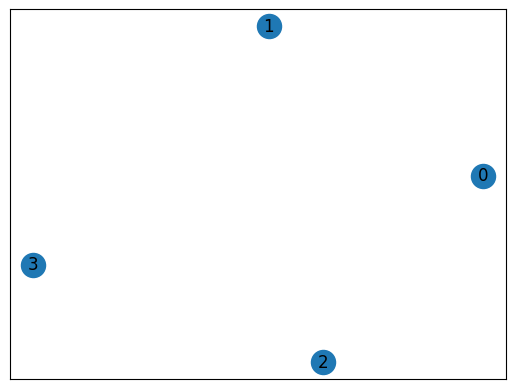

In [38]:
from networkx.drawing.nx_pydot import write_dot
G = graph
write_dot(G, "graph.dot")

pos = nx.spring_layout(G)

nx.draw_networkx_nodes(G, pos)
nx.draw_networkx_labels(G, pos)
nx.draw_networkx_edges(G, pos, edge_color='r', arrows = True)

In [30]:
[(1, 4), (3, 5), (3, 6), (4, 7), (5, 7)]

[3, 3, 3, 3, 3, 2, 3, 2]

In [ ]:

import networkx as nx

# Define variables and data
vars = ["A", "B", "C", "D"]  # Variable names
# Generate random dataset where each variable can take 3 possible values
D = np.random.randint(0, 3, size=(100, 4))  # Random dataset (100 samples, 4 variables)

# Create a sample graph (NetworkX)
G = nx.DiGraph()
G.add_edges_from([(0, 1), (1, 2), (2, 3)])

# Compute the Bayesian score for the graph and data
score = bayesian_score(vars, G, D)
print("Bayesian score:", score)

In [9]:

from scipy.stats import chi2_contingency

def are_independent(df, col1, col2):
  contingency_table = pd.crosstab(df[col1], df[col2])
  chi2, p, dof, expected = chi2_contingency(contingency_table)
  return p > 0.05  # If p-value is greater than 0.05, we consider them independent

for col1 in df_small.columns:
  for col2 in df_small.columns:
    if col1 != col2:
      if are_independent(df_small, col1, col2):
        print(f"{col1} and {col2} are likely independent.")


age and fare are likely independent.
age and survived are likely independent.
fare and age are likely independent.
fare and numsiblings are likely independent.
numparentschildren and passengerclass are likely independent.
passengerclass and numparentschildren are likely independent.
sex and numsiblings are likely independent.
numsiblings and fare are likely independent.
numsiblings and sex are likely independent.
survived and age are likely independent.


In [34]:
# create an empty directed graph
G = nx.DiGraph()

# add edges (and implicitly nodes) from Q2a
G.add_edges_from([["H", "A"],
                  ["A", "B"],
                  ["B", "E"],
                  ["E", "J"],
                  ["E", "I"],
                  ["C", "B"],
                  ["D", "C"],
                  ["F", "D"],
                  ["F", "G"],
                  ["G", "C"],
                  ["G", "H"]])

# define the evidence variables (as set)
evidence_variables = {"I", "G"}

# nx.is_d_separator returns bool whether D is cond. independent
# given the set of `evidence_variables`
d_sep = nx.is_d_separator(G, "D", "H", evidence_variables)

# you should see "D-Connected" due to path 4 from Q2a (see solutions)
if d_sep:
    print("Q2a: D-Separated")
else:
    print("Q2a: D-Connected")

# verify the solution we found in Q2b using the Markov blanket
# (adding C to the set of `evidence_variables`)
evidence_variables = evidence_variables.union({"C"})

d_sep = nx.is_d_separator(G, "D", "H", evidence_variables)

# you should see "D-Separated" as we fixed path 4
if d_sep:
    print("Q2b: D-Separated")
else:
    print("Q2b: D-Connected")

Q2a: D-Connected
Q2b: D-Separated


In [5]:
# create an empty directed graph
G = nx.DiGraph()

# add edges (and implicitly nodes) from Q2a
G.add_edges_from([["H", "A"],
                  ["A", "B"],
                  ["B", "E"],
                  ["E", "J"],
                  ["E", "I"],
                  ["C", "B"],
                  ["D", "C"],
                  ["F", "D"],
                  ["F", "G"],
                  ["G", "C"],
                  ["G", "H"]])

# define the evidence variables (as set)
evidence_variables = {"I", "G"}

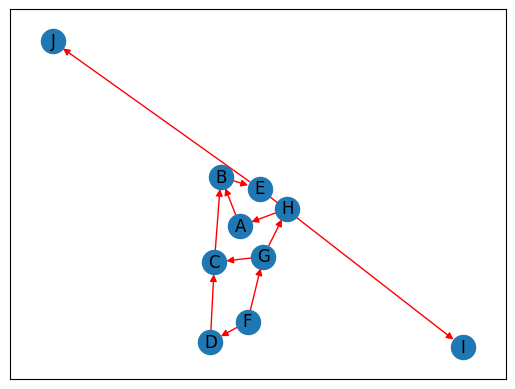

In [7]:
from networkx.drawing.nx_pydot import write_dot

write_dot(G, "graph.dot")

pos = nx.spring_layout(G)

nx.draw_networkx_nodes(G, pos)
nx.draw_networkx_labels(G, pos)
nx.draw_networkx_edges(G, pos, edge_color='r', arrows = True)

In [10]:
for edge in graph.edges():
  print(edge[0])

In [8]:
def write_gph(dag, idx2names, filename):
    with open(filename, 'w') as f:
        for edge in dag.edges():
            f.write("{}, {}\n".format(idx2names[edge[0]], idx2names[edge[1]]))

write_gph(G, [1,2,3,4,5,6,7,8], 'huh.gph')

TypeError: list indices must be integers or slices, not str

In [56]:
list(df_small.columns)

['age',
 'portembarked',
 'fare',
 'numparentschildren',
 'passengerclass',
 'sex',
 'numsiblings',
 'survived']

In [48]:
G.get_edge_data("H","A").astype()# == True

AttributeError: 'dict' object has no attribute 'astype'

In [30]:
nx.graphviews.generic_graph_view(G)

In [2]:
# prompt: read from csv in a folder called Data

import sys
import networkx
import pandas as pd



def write_gph(dag, idx2names, filename):
    with open(filename, 'w') as f:
        for edge in dag.edges():
            f.write("{}, {}\n".format(idx2names[edge[0]], idx2names[edge[1]]))


def compute(infile, outfile):
    # WRITE YOUR CODE HERE
    # FEEL FREE TO CHANGE ANYTHING ANYWHERE IN THE CODE
    # THIS INCLUDES CHANGING THE FUNCTION NAMES, MAKING THE CODE MODULAR, BASICALLY ANYTHING
    df_small = pd.read_csv("AA228-CS238-Student/project1/data/small.csv")
    print(df_small)
    # ... rest of your code to process the dataframe ...
    pass


def main():
    if len(sys.argv) != 3:
        raise Exception("usage: python project1.py <infile>.csv <outfile>.gph")

    inputfilename = sys.argv[1]
    outputfilename = sys.argv[2]
    compute(inputfilename, outputfilename)


if __name__ == '__main__':
    main()


FileNotFoundError: [Errno 2] No such file or directory: 'AA228-CS238-Student/project1/data/small.csv'

In [2]:
!git clone https://github.com/girlofimpulse/AA228-CS238-Student.git

Cloning into 'AA228-CS238-Student'...
remote: Enumerating objects: 146, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 146 (delta 27), reused 41 (delta 14), pack-reused 71 (from 1)
Receiving objects: 100% (146/146), 3.84 MiB | 4.12 MiB/s, done.
Resolving deltas: 100% (49/49), done.


AA228-CS238-Student  sample_data
